In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mPk import compute_matter_power_spectrum
import glob
import re
import os
from scipy.stats import binned_statistic
from scipy.interpolate import interp1d

from classy_NEDE import Class as Class_NEDE

import matplotlib as mpl

plt.rcParams.update(plt.rcParamsDefault)

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "xtick.top": True,
    "ytick.right": True,
})

In [3]:
# ----------------------------
# 0) Common CLASS settings
# ----------------------------
zPk = "50.0,0"                      
k_targets = np.array([0.05, 0.5, 1.0])   # Added 0.5 
kstr = ",".join(str(x) for x in k_targets) # e.g. "0.05,0.5,1.0"

base_dict = {
    'h': 0.6766,
    'omega_b': 0.02242,
    'omega_cdm': 0.1192,
    'A_s': 2.107699e-9,
    'n_s': 0.9671182,
    'output': 'mTk, mPk, vTk',
    'lensing': 'no',

    # neutrino sector (your baseline)
    'N_ur': 2.0328,
    'N_ncdm': 1,
    'deg_ncdm': 1,
    'm_ncdm': 0.06,
    'T_ncdm': 0.71611,

    'YHe': 0.245,

    'z_pk': zPk,
    'k_output_values': kstr,
    'P_k_max_1/Mpc': 15.0,
    'k_pivot': 0.05,

    # 'k_per_decade_for_pk': 100,
    # 'k_per_decade_for_bao': 200,
}

# ----------------------------
# 1) Baseline NEDE parameters
# ----------------------------
NEDE_params = {
    'l_switch_limber': 9,
    'delta_Neff_drmd': 0.83,
    'z_stop': 10**(4.83),
    'f_idm_drmd': 0.0285,
    'G_over_aH_drmd_ini': 10**(13.057),
}

# ----------------------------
# 2) 1σ definitions (self-consistent)
# ----------------------------
# For some parameters you typically want *additive* 1σ (like delta_Neff and f_idm).
# For others you often want *fractional* 1σ (≈10%) rather than adding a huge absolute number.
NEDE_sigma_add = {
    'delta_Neff_drmd': 0.462 / 2,   # additive 1σ (from paper)
    'f_idm_drmd': 0.0152 / 2,       # additive 1σ (from paper)
}

# "Around 10%" -> define fractional sigmas (dimensionless)
NEDE_sigma_frac = {
    'z_stop': 0.10,
    'G_over_aH_drmd_ini': 0.10,
}

# ----------------------------
# 3) LCDM "turn off DRMD" params
# ----------------------------
LCDM_params = {
    'delta_Neff_drmd': 0.0,
    'f_idm_drmd': 0.0,
    'G_over_aH_drmd_ini': 0.0,
    'z_stop': 0.0
}

# ----------------------------
# 4) Utilities: shifting params
# ----------------------------
def shifted_NEDE_params(sigma_shifts=None, raw_overrides=None):
    """
    Returns a dict of NEDE parameters after applying n-sigma shifts and raw overrides.

    sigma_shifts: dict like {'delta_Neff_drmd': +1, 'z_stop': -1, ...}
                  Interpretation:
                    - if key in NEDE_sigma_add: p <- p + n*sigma_add
                    - if key in NEDE_sigma_frac: p <- p * (1 + n*sigma_frac)
                  (So z_stop/G_over_aH vary multiplicatively.)
    raw_overrides: dict of exact values to set after sigma shifts (highest priority).
    """
    p = NEDE_params.copy()

    if sigma_shifts:
        for key, n in sigma_shifts.items():
            if key in NEDE_sigma_add:
                p[key] = p[key] + n * NEDE_sigma_add[key]
            elif key in NEDE_sigma_frac:
                frac = NEDE_sigma_frac[key]
                p[key] = p[key] * (1.0 + n * frac)
            else:
                raise KeyError(
                    f"'{key}' not configured in NEDE_sigma_add or NEDE_sigma_frac. "
                    f"Add it to one of them."
                )

    if raw_overrides:
        p.update(raw_overrides)

    return p

# ----------------------------
# 5) One consistent builder for NEDE and effective LCDM
# ----------------------------
def build_cosmo(model="NEDE", sigma_shifts=None, raw_overrides=None):
    d = base_dict.copy()

    # Get the shifted NEDE parameter set
    p = shifted_NEDE_params(sigma_shifts=sigma_shifts, raw_overrides=raw_overrides)

    if model == "NEDE":
        d.update(p)

    elif model == "LCDM_eff":
        d.update(LCDM_params)
        
        # Map delta_Neff_drmd into N_ur
        d['N_ur'] = base_dict['N_ur'] + p['delta_Neff_drmd']
        
        # In LCDM, f_idm is 0, so omega_cdm is just the total dark matter.
        # We don't need to change omega_cdm from the base_dict value.

    else:
        raise ValueError("model must be 'NEDE' or 'LCDM_eff'")

    cosmo = Class_NEDE()
    cosmo.set(d)
    cosmo.compute()
    return cosmo

# ----------------------------
# 6) Examples: explicit cosmologies
# ----------------------------
cosmo_NEDE = build_cosmo("NEDE")
cosmo_LCDM = build_cosmo("LCDM_eff", raw_overrides={'delta_Neff_drmd': 0.0, 'f_idm_drmd': 0.0, 'G_over_aH_drmd_ini': 0.0, 'z_stop': 0.0})
cosmo_SIDR = build_cosmo("NEDE", raw_overrides={'f_idm_drmd': 0.0})
cosmo_NEDE_zlow = build_cosmo("NEDE", raw_overrides={'z_stop': 10**4.66})
cosmo_NEDE_zhigh = build_cosmo("NEDE", raw_overrides={'z_stop': 10**5.00})
cosmo_NEDE_Glow = build_cosmo("NEDE", raw_overrides={'G_over_aH_drmd_ini': 10**12})
cosmo_NEDE_Ghigh = build_cosmo("NEDE", raw_overrides={'G_over_aH_drmd_ini': 10**14})

In [4]:
# Extract P(k)
res_LCDM = compute_matter_power_spectrum(cosmo_LCDM, z=0.0)
res_SIDR       = compute_matter_power_spectrum(cosmo_SIDR, z=0.0)
res_DRMD       = compute_matter_power_spectrum(cosmo_NEDE, z=0.0)
res_DRMD_zLow  = compute_matter_power_spectrum(cosmo_NEDE_zlow, z=0.0)
res_DRMD_zHigh = compute_matter_power_spectrum(cosmo_NEDE_zhigh, z=0.0)
res_DRMD_GLow  = compute_matter_power_spectrum(cosmo_NEDE_Glow, z=0.0)
res_DRMD_GHigh = compute_matter_power_spectrum(cosmo_NEDE_Ghigh, z=0.0)

k_LCDM       = res_LCDM['k']
k_SIDR       = res_SIDR['k']
k_DRMD       = res_DRMD['k']
k_DRMD_zLow  = res_DRMD_zLow['k']
k_DRMD_zHigh = res_DRMD_zHigh['k']
k_DRMD_GLow  = res_DRMD_GLow['k']
k_DRMD_GHigh = res_DRMD_GHigh['k']

Pk_LCDM       = res_LCDM['P_k']
Pk_SIDR       = res_SIDR['P_k']
Pk_DRMD       = res_DRMD['P_k']
Pk_DRMD_zLow  = res_DRMD_zLow['P_k']
Pk_DRMD_zHigh = res_DRMD_zHigh['P_k']
Pk_DRMD_GLow  = res_DRMD_GLow['P_k']
Pk_DRMD_GHigh = res_DRMD_GHigh['P_k']

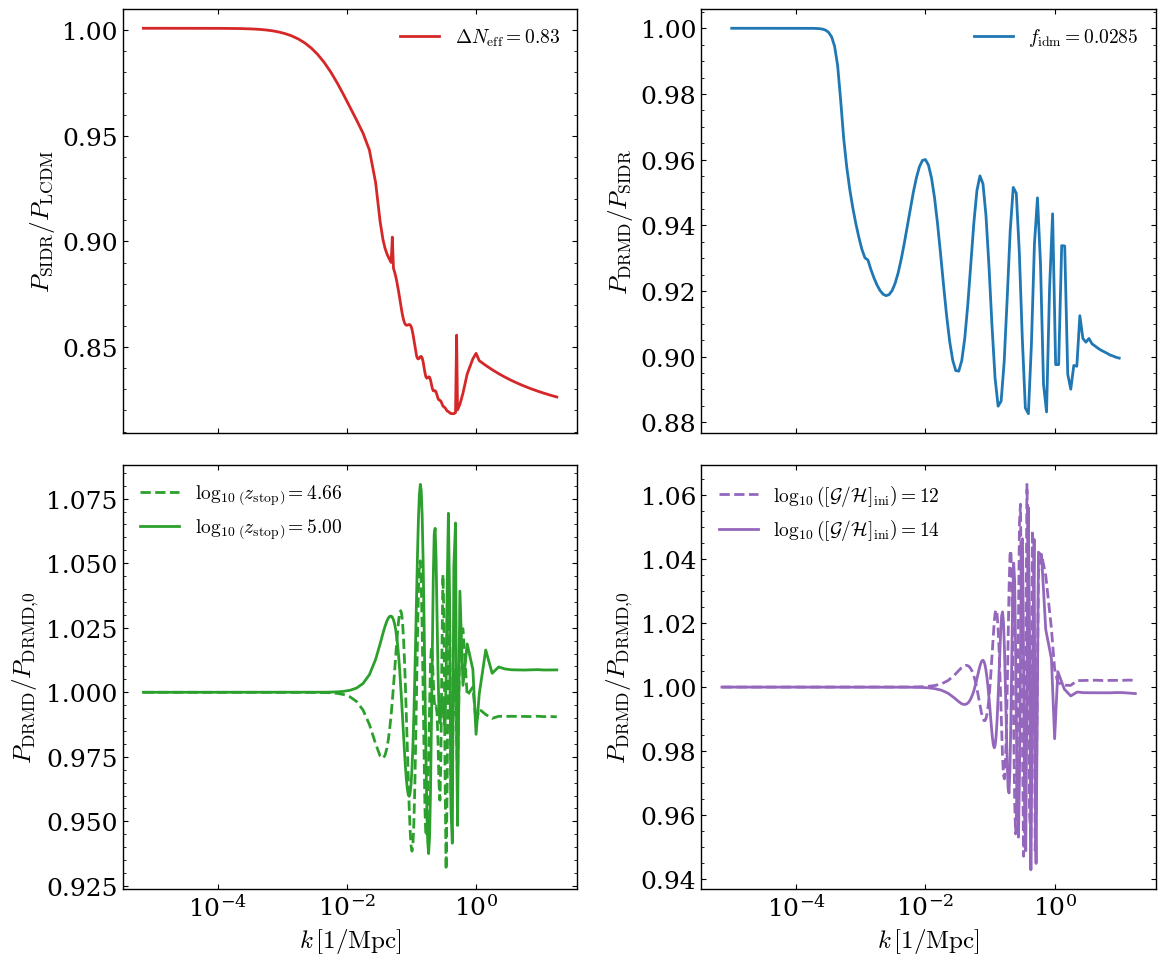

In [ ]:
# ----------------------------
# 4) Plotting the Isolated Effects
# ----------------------------
# Changed to 2x2 grid, adjusted figsize for better proportions
fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

# Panel 1: Pure effect of delta_Neff (SIDR vs LCDM)
ax[0, 0].semilogx(k_SIDR, (Pk_SIDR / Pk_LCDM), color='tab:red', label = r'$\Delta N_{\mathrm{eff}} = 0.83$')
ax[0, 0].set_ylabel(r'$P_{\text{SIDR}} / P_{\text{LCDM}}$')
ax[0, 0].legend()


# Panel 2: Pure effect of f_idm (DRMD vs SIDR)
ax[0, 1].semilogx(k_DRMD, (Pk_DRMD / Pk_SIDR), color='tab:blue', label=r'$f_{\mathrm{idm}} = 0.0285$')
ax[0, 1].set_ylabel(r'$P_{\text{DRMD}} / P_{\text{SIDR}}$')
ax[0, 1].legend()

# Panel 3: Effect of varying z_stop (relative to baseline DRMD)
ax[1, 0].semilogx(k_DRMD_zLow, (Pk_DRMD_zLow / Pk_DRMD), color='tab:green', linestyle='--', label=r'$\log_{10}\left(z_{\text{stop}}\right) = 4.66$')
ax[1, 0].semilogx(k_DRMD_zHigh, (Pk_DRMD_zHigh / Pk_DRMD), color='tab:green', linestyle='-', label=r'$\log_{10}\left(z_{\text{stop}}\right) = 5.00$')
ax[1, 0].set_xlabel(r"$k\,[1/\mathrm{Mpc}]$")
ax[1, 0].set_ylabel(r'$P_{\text{DRMD}} / P_{\text{DRMD,0}}$')
ax[1, 0].legend()

# Panel 4: Effect of varying G/aH (relative to baseline DRMD)
ax[1, 1].semilogx(k_DRMD_GLow, (Pk_DRMD_GLow / Pk_DRMD), color='tab:purple', linestyle='--', label=r'$\log_{10}\left([\mathcal{G}/\mathcal{H}]_{\text{ini}}\right) = 12$')
ax[1, 1].semilogx(k_DRMD_GHigh, (Pk_DRMD_GHigh / Pk_DRMD), color='tab:purple', linestyle='-', label=r'$\log_{10}\left([\mathcal{G}/\mathcal{H}]_{\text{ini}}\right) = 14$')
ax[1, 1].set_xlabel(r"$k\,[1/\mathrm{Mpc}]$")
ax[1, 1].set_ylabel(r'$P_{\text{DRMD}} / P_{\text{DRMD,0}}$')
ax[1, 1].legend()

plt.tight_layout()
plt.show()
# fig.savefig('DRMD_lin_mPk_effects.pdf', bbox_inches = 'tight')

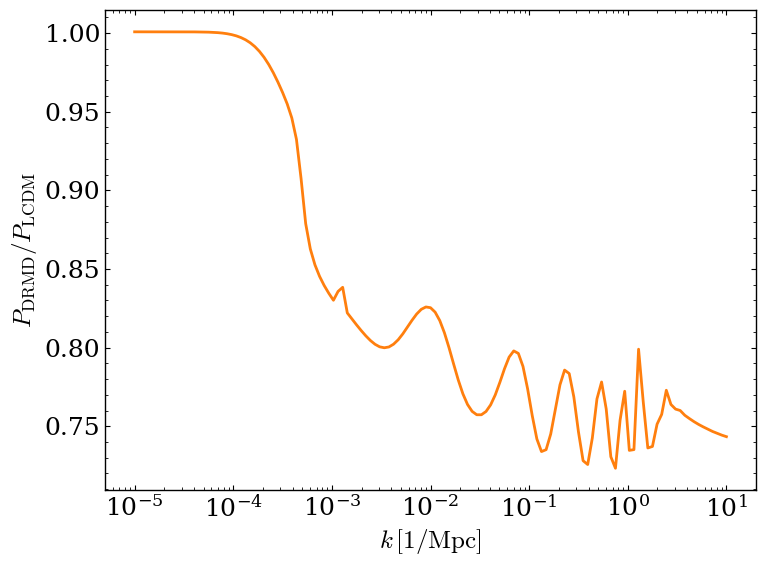

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
# Plot the baseline DRMD P(k) divided by LCDM for reference
ax.semilogx(k_DRMD, (Pk_DRMD / Pk_LCDM), color='tab:orange', label=r'Baseline DRMD / $\Lambda$CDM')
ax.set_xlabel(r"$k\,[1/\mathrm{Mpc}]$")
ax.set_ylabel(r'$P_{\text{DRMD}} / P_{\text{LCDM}}$')
plt.tight_layout()
plt.show()

# fig.savefig('DRMD_LCDM_mPk_res.pdf', bbox_inches = 'tight')

In [5]:
back_LCDM = cosmo_LCDM.get_background()
z = back_LCDM['z']
a = 1 / (1 + z)
# with both your LambdaCDM model and your NEDE model later.
rho_m = back_LCDM['(.)rho_b'] + back_LCDM['(.)rho_cdm'] + back_LCDM.get('(.)rho_idm_drmd', np.zeros_like(a))
rho_r = back_LCDM['(.)rho_g'] + back_LCDM['(.)rho_ur'] + back_LCDM.get('(.)rho_drmd', np.zeros_like(a))
rho_l = back_LCDM['(.)rho_lambda']
rho_tot = back_LCDM['(.)rho_tot']

ratio = rho_m / rho_r
ratio2 = rho_l / rho_m
a_eq = np.interp(1.0, ratio, a)
a_eq2 = np.interp(1.0, ratio2, a)
H_eq = np.interp(a_eq, a, back_LCDM['H [1/Mpc]'])
H_eq2 = np.interp(a_eq2, a, back_LCDM['H [1/Mpc]'])
k_eq = a_eq * H_eq
k_eq2 = a_eq2 * H_eq2

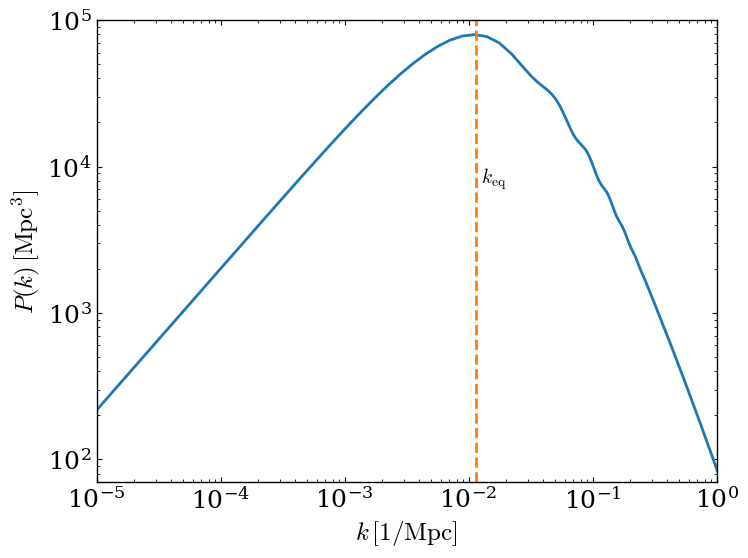

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(k_LCDM, Pk_LCDM, color='tab:blue')
ax.set_xlabel(r'$k \, [1/\mathrm{Mpc}]$')
ax.set_ylabel(r'$P(k) \, [\mathrm{Mpc}^3]$')
ax.vlines(k_eq, ymin=7e1, ymax=1e5, color='tab:orange', linestyle='--')
# ax.vlines(k_eq2, ymin=7e1, ymax=1e5, color='tab:green', linestyle='--')
ax.set_xlim(1e-5, 1)
ax.set_ylim(7e1, 1e5)

# Insert text saying k_eq
ax.text(k_eq * 1.1, 1e4, r'$k_\mathrm{eq}$', color='k', fontsize=14, verticalalignment='top')
# ax.text(k_eq2 * 1.1, 1e4, r'$k_\Lambda$', color='k', fontsize=14, verticalalignment='top')
plt.show()

fig.savefig('LCDM_lin_mPk.pdf', bbox_inches = 'tight', dpi = 300)

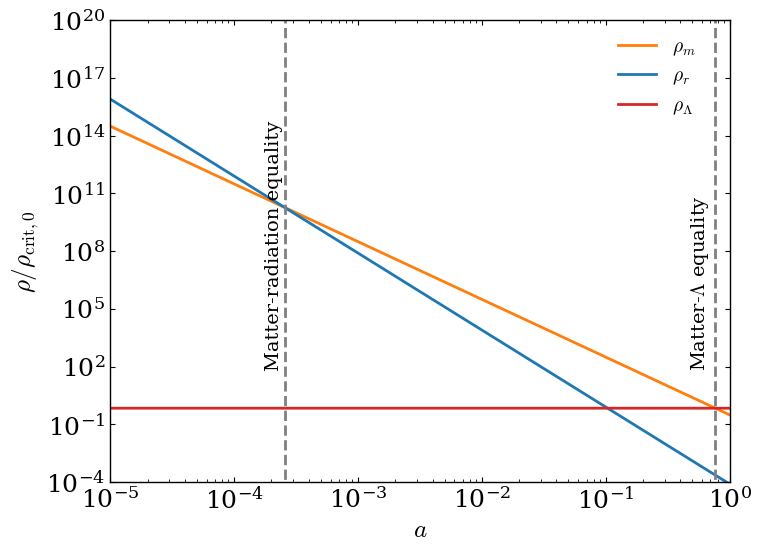

In [7]:
# Make a plot of rho_m, rho_r, and rho_l as a function of a, with vertical lines at a_eq and a_eq2
fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(a, rho_m / rho_tot[-1], label=r'$\rho_m$', color = 'tab:orange')
ax.loglog(a, rho_r / rho_tot[-1], label=r'$\rho_r$', color = 'tab:blue')
ax.loglog(a, rho_l / rho_tot[-1], label=r'$\rho_\Lambda$', color = 'tab:red')
ax.set_xlabel(r'$a$')
ax.set_ylabel(r'$\rho / \rho_{\mathrm{crit},0}$')
ax.vlines(a_eq, ymin=1e-10, ymax=1e20, color='grey', linestyle='--')
ax.vlines(a_eq2, ymin=1e-10, ymax=1e20, color='grey', linestyle='--')
# Insert text saying matter-radiation equality and matter-lambda equality
ax.text(a_eq * 0.7, 5.9e+1, r'Matter-radiation equality', color='k', fontsize=14, verticalalignment='bottom', rotation = 'vertical')
ax.text(a_eq2 - 0.3, 5.9e+1, r'Matter-$\Lambda$ equality', color='k', fontsize=14, verticalalignment='bottom', rotation = 'vertical')
ax.set_xlim(1e-5, 1.01)
ax.set_ylim(1e-4, 1e20)
ax.legend(bbox_to_anchor=(0.79, 1), loc='upper left')

# Save the figure
plt.show()
fig.savefig('rho(a).pdf', bbox_inches = 'tight', dpi = 300)

In [9]:
a_eq2

np.float64(0.7656804396204794)

In [10]:
DRMD_deltas = cosmo_NEDE.get_transfer()
LCDM_deltas = cosmo_LCDM.get_transfer()

print(DRMD_deltas.keys())

DRMD_delta_m = DRMD_deltas['d_m']
LCDM_delta_m = LCDM_deltas['d_m']
DRMD_k = DRMD_deltas['k (h/Mpc)']
LCDM_k = LCDM_deltas['k (h/Mpc)']
h = base_dict['h']
DRMD_k = DRMD_k * h
LCDM_k = LCDM_k * h


dict_keys(['k (h/Mpc)', 'd_g', 'd_b', 'd_cdm', 'd_idm_drmd', 'd_ur', 'd_idr_drmd', 'd_ncdm[0]', 'd_m', 'd_tot', 'phi', 'psi', 't_g', 't_b', 't_idm_drmd', 't_ur', 't_idr_drmd', 't_ncdm[0]', 't_tot'])


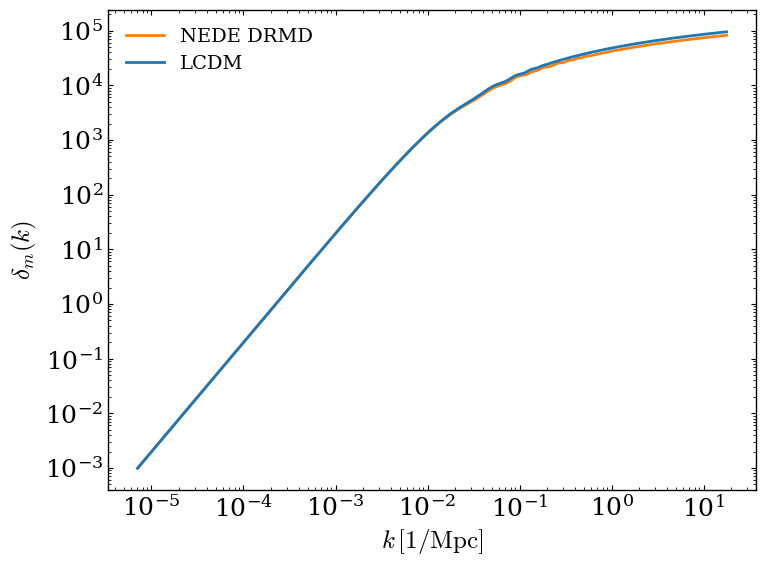

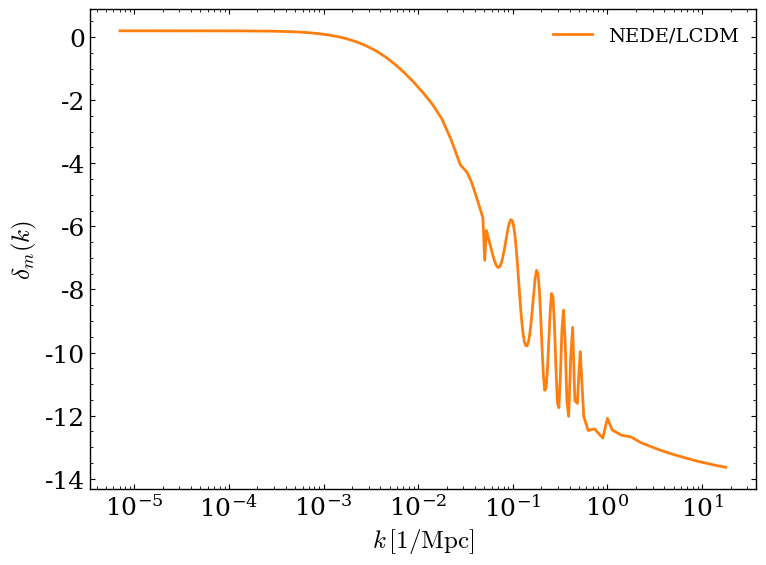

In [11]:
# Plot the matter transfer functions
fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(DRMD_k, np.abs(DRMD_delta_m), label='NEDE DRMD', color='tab:orange')
ax.loglog(LCDM_k, np.abs(LCDM_delta_m), label='LCDM', color='tab:blue')
ax.set_xlabel(r'$k \, [1/\mathrm{Mpc}]$')
ax.set_ylabel(r'$\delta_m(k)$')
ax.legend()
plt.tight_layout()
plt.show()
# Plot the matter transfer functions
fig, ax = plt.subplots(figsize=(8, 6))
ax.semilogx(DRMD_k, (np.abs(DRMD_delta_m) / np.abs(LCDM_delta_m) - 1) * 100, label='NEDE/LCDM', color='tab:orange')
ax.set_xlabel(r'$k \, [1/\mathrm{Mpc}]$')
ax.set_ylabel(r'$\delta_m(k)$')
ax.legend()
plt.tight_layout()
plt.show()

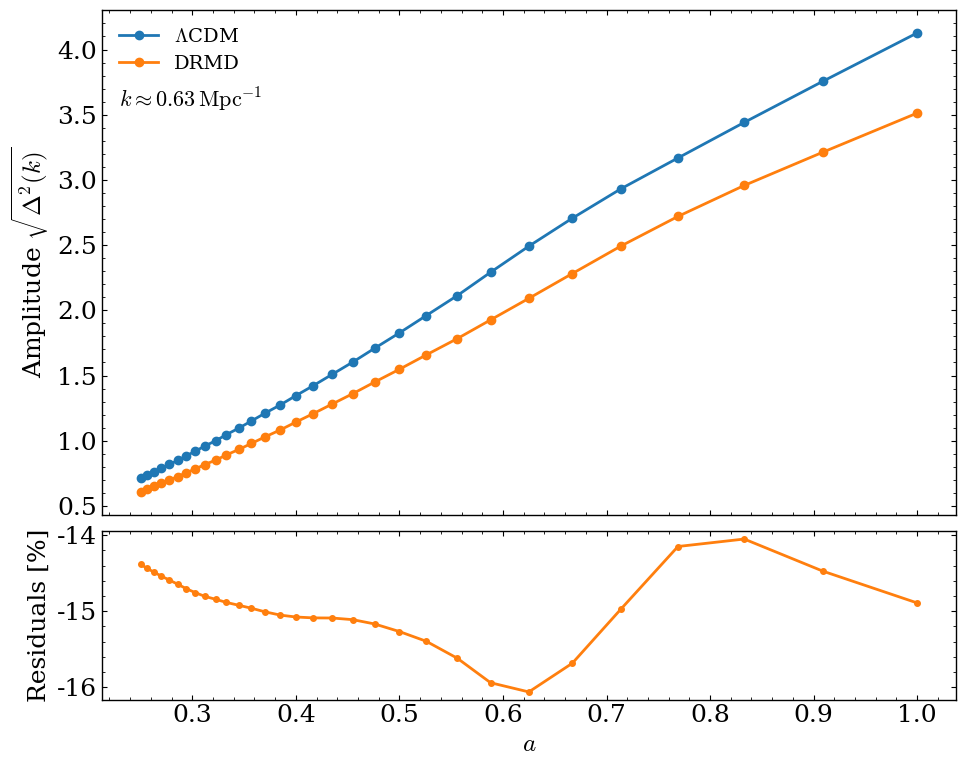

In [12]:
def get_delta_evolution(directory, target_k):
    """
    Reads all CONCEPT power spectrum files in a directory and extracts
    the dimensionless amplitude sqrt(Delta^2) for a specific k-value.
    """
    search_pattern = os.path.join(directory, 'powerspec_size512_lpt2_a=*')
    all_files = glob.glob(search_pattern)
    data_files = [f for f in all_files if not f.endswith('.png')]
    
    a_values = []
    delta_nl = []  # Dimensionless non-linear amplitude
    delta_lin = [] # Dimensionless linear amplitude
    
    for file in data_files:
        basename = os.path.basename(file)
        a_str = basename.split('a=')[-1]
        a = float(a_str)
        a_values.append(a)
        
        data = np.loadtxt(file, comments='#')
        k_array = data[:, 0]
        p_nl_array = data[:, 2]
        p_lin_array = data[:, 4]
        
        idx = (np.abs(k_array - target_k)).argmin()
        actual_k = k_array[idx] # Use the exact k from the file
        
        # Calculate Delta^2 = k^3 * P(k) / (2 * pi^2)
        factor = (actual_k**3) / (2 * np.pi**2)
        
        delta_nl.append(np.sqrt(p_nl_array[idx] * factor))
        delta_lin.append(np.sqrt(p_lin_array[idx] * factor))
        
    sort_indices = np.argsort(a_values)
    a_values = np.array(a_values)[sort_indices]
    delta_nl = np.array(delta_nl)[sort_indices]
    delta_lin = np.array(delta_lin)[sort_indices]
    
    return a_values, delta_nl, delta_lin

# --- Main Script ---
target_k = 0.6  # Mpc^-1 (using the recommended value for the spoon)

dir_planck = '/home/storgaard/OneDrive/concept/grendel_output/256/planck/powerspec'
dir_drmd ='/home/storgaard/OneDrive/concept/grendel_output/256/baseline/powerspec'

a_planck, d_nl_planck, d_lin_planck = get_delta_evolution(dir_planck, target_k)
a_drmd, d_nl_drmd, d_lin_drmd = get_delta_evolution(dir_drmd, target_k)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})

# Top Plot
ax1.plot(a_planck, d_nl_planck, '-o', color='tab:blue', label=r'$\Lambda$CDM')
# ax1.plot(a_planck, d_lin_planck, '--', color='tab:blue', alpha=0.6, label='Planck (Linear)')
ax1.plot(a_drmd, d_nl_drmd, '-o', color='tab:orange', label='DRMD')
# ax1.plot(a_drmd, d_lin_drmd, '--', color='tab:orange', alpha=0.6, label='DRMD (Linear)')

# Notice the updated y-axis label
ax1.set_ylabel(r'Amplitude $\sqrt{\Delta^2(k)}$')
ax1.legend()
# Input text sayin k is approximately 0.63
ax1.text(0.02, 0.85, r"$k \approx 0.63 \, \mathrm{Mpc}^{-1}$", 
               transform=ax1.transAxes, fontsize=16, va='top', 
               bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Bottom Plot (Residuals remain mathematically identical, just calculated from Delta now)
residuals_nl_pct = (d_nl_drmd / d_nl_planck - 1) * 100
residuals_lin_pct = (d_lin_drmd / d_lin_planck - 1) * 100

# ax2.axhline(0, color='black', linestyle='--', alpha=0.6)
ax2.plot(a_planck, residuals_nl_pct, 'o-', markersize=4, color='tab:orange', label='N-body')
# ax2.plot(a_planck, residuals_lin_pct, 's--', markersize=4, color='tab:orange', alpha=0.6, label='Linear')

ax2.set_ylabel('Residuals [%]')
ax2.set_xlabel('$a$')

plt.tight_layout()
plt.subplots_adjust(hspace=0.05) 
plt.show()

# Save the figure
# fig.savefig('DRMD_Pk_evolution_k0.63.pdf', bbox_inches='tight')

Loading baseline...
Loading dNeff = 0.5...
Loading dNeff = 1.0...
Loading dNeff = 1.5...
Loading dNeff = 2.0...
Loading dNeff = -0.5...
Loading dNeff = -1.0...
Loading dNeff = -1.5...
Loading dNeff = -2.0...
Loading fidm = 0.5...
Loading fidm = 1.0...
Loading fidm = 1.5...
Loading fidm = 2.0...
Loading fidm = -0.5...
Loading fidm = -1.0...
Loading fidm = -1.5...
Loading fidm = -2.0...

Response functions, weights, and binned arrays cached using 25 log-bins!


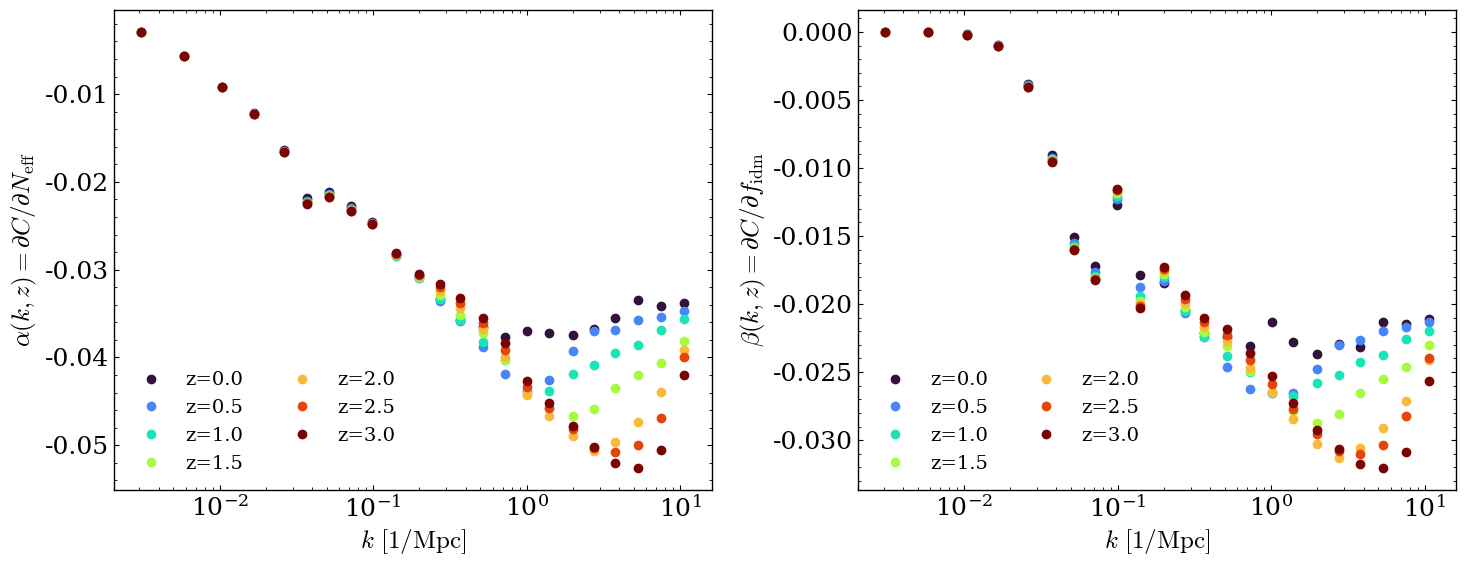

In [14]:
import os
import re
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

# =================================================================
# 1. SETUP & LOADING
# =================================================================
BASE_DIR = '/home/storgaard/OneDrive/Speciale/Halofit/C_256+2048_not_cut' 

def load_sim_folder(folder_path):
    """Loads all z-files in a folder into a dictionary: data[z_val] = (k, Ck)"""
    files = glob.glob(os.path.join(folder_path, "Ck_z*.txt"))
    data_dict = {}
    for f in files:
        match = re.search(r'Ck_z([\d\.]+)\.txt', os.path.basename(f))
        if match:
            z_val = round(float(match.group(1)), 2)
            data = np.loadtxt(f, skiprows=1)
            data_dict[z_val] = (data[:, 0], data[:, 1])
    return data_dict

print("Loading baseline...")
base_data = load_sim_folder(os.path.join(BASE_DIR, "baseline")) 

var_data = {'dNeff': {}, 'fidm': {}}
for folder_name in os.listdir(BASE_DIR):
    if folder_name == "baseline": continue
        
    match = re.match(r'(dNeff|fidm)_([+-]?[\d\.]+)', folder_name)
    if not match: continue
        
    param_name = match.group(1)
    delta_val = float(match.group(2))
    
    print(f"Loading {param_name} = {delta_val}...")
    var_data[param_name][delta_val] = load_sim_folder(os.path.join(BASE_DIR, folder_name))

# =================================================================
# 2. LOG-BINNING AND CALCULATING RESPONSE FUNCTIONS
# =================================================================
n_log_bins = 25

response_functions = {'dNeff': {}, 'fidm': {}} 

# Dictionaries to store the binned data so we NEVER bin twice
binned_base = {} 
binned_var = {'dNeff': {}, 'fidm': {}}

for param in ['dNeff', 'fidm']:
    delta_vals = np.array(list(var_data[param].keys()))
    if len(delta_vals) == 0: continue
        
    for z in base_data.keys():
        k_raw, Ck_base_raw = base_data[z]
        
        # Data is no longer cut; using the full k_raw and Ck_base_raw
        bins = np.logspace(np.log10(k_raw.min()), np.log10(k_raw.max()), n_log_bins + 1)
        
        k_binned, _, _  = binned_statistic(k_raw, k_raw, statistic='mean', bins=bins)
        Ck_base_binned, _, _ = binned_statistic(k_raw, Ck_base_raw, statistic='mean', bins=bins)
        
        nan_mask = ~np.isnan(k_binned) & ~np.isnan(Ck_base_binned)
        k_binned = k_binned[nan_mask]
        Ck_base_binned = Ck_base_binned[nan_mask]
        
        # Save baseline to dictionary
        if z not in binned_base:
            binned_base[z] = (k_binned, Ck_base_binned)
        
        y_matrix = []
        valid_x = []
        
        for d_val in delta_vals:
            if z in var_data[param][d_val]:
                _, Ck_var_raw = var_data[param][d_val][z]
                
                # Using full Ck_var_raw without the valid_mask
                Ck_var_binned, _, _ = binned_statistic(k_raw, Ck_var_raw, statistic='mean', bins=bins)
                Ck_var_binned = Ck_var_binned[nan_mask]
                
                # Save varied model to dictionary
                if d_val not in binned_var[param]:
                    binned_var[param][d_val] = {}
                binned_var[param][d_val][z] = (k_binned, Ck_var_binned)
                
                y_matrix.append(Ck_var_binned - Ck_base_binned)
                valid_x.append(d_val)
                
        y_matrix = np.array(y_matrix)
        valid_x = np.array(valid_x)
        
        if len(valid_x) > 0:
            numerator = np.dot(valid_x, y_matrix) 
            denominator = np.sum(valid_x**2)
            slope_array = numerator / denominator
            
            sigma_array = np.ones_like(k_binned)
            if param == 'fidm' and z > 0.3:
                emphasis_mask = k_binned > 1.5
                sigma_array[emphasis_mask] = 0.1
            
            response_functions[param][z] = (k_binned, slope_array, sigma_array)

print(f"\nResponse functions, weights, and binned arrays cached using {n_log_bins} log-bins!")

# =================================================================
# 3. PLOT THE RESPONSE FUNCTIONS
# =================================================================
# Dynamically pull ALL available redshifts and sort them
z_to_plot = sorted(list(base_data.keys()))[::5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

cmap = plt.get_cmap('turbo') 
z_min, z_max = min(z_to_plot), max(z_to_plot)
norm = mpl.colors.Normalize(vmin=z_min, vmax=z_max)

# Plot alpha(k) for dNeff (Left - ax1)
if 'dNeff' in response_functions and response_functions['dNeff']:
    for z in z_to_plot:
        color = cmap(norm(z))
        if z in response_functions['dNeff']:
            k, alpha, _ = response_functions['dNeff'][z]
            ax1.plot(k, alpha, color=color, label=f'z={z}', ls='None', marker='o')
            
    ax1.set_xscale('log')
    ax1.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
    ax1.set_ylabel(r'$\alpha(k, z) = \partial C / \partial N_{\mathrm{eff}}$')
    ax1.legend(loc='lower left', ncols=2,)


# Plot beta(k) for fidm (Right - ax2)
if 'fidm' in response_functions and response_functions['fidm']:
    for z in z_to_plot:
        if z in response_functions['fidm']:
            k, beta, _ = response_functions['fidm'][z]
            color = cmap(norm(z))
            ax2.plot(k, beta, color=color, label=f'z={z}', ls='None', marker='o')
            
    ax2.set_xscale('log')
    ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
    ax2.set_ylabel(r'$\beta(k, z) = \partial C / \partial f_{\mathrm{idm}}$')
    ax2.legend(loc='lower left', ncols=2,)

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig('alpha_beta.pdf', bbox_inches='tight')

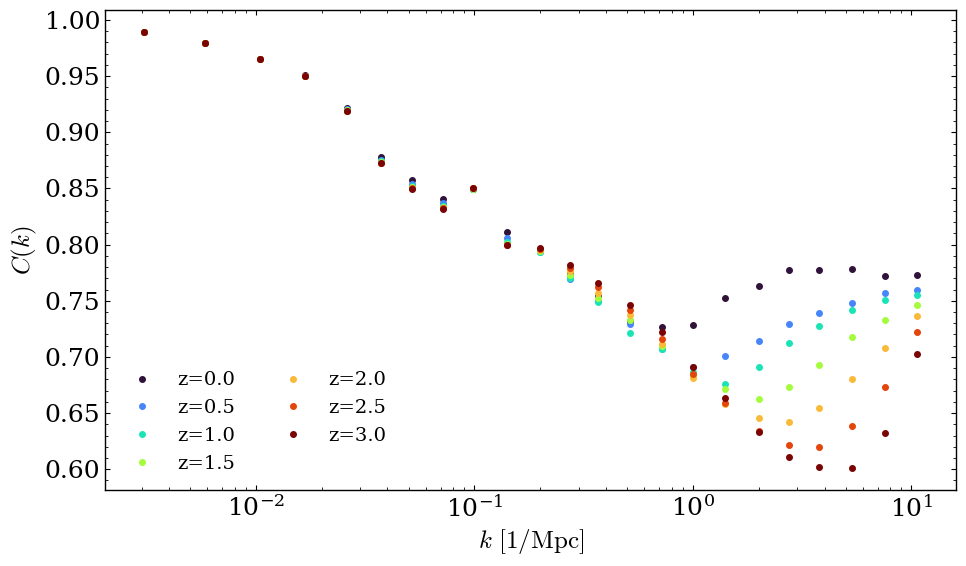

In [15]:
# =================================================================
# 4. PLOT BINNED BASELINE DATA
# =================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Re-using the subset of redshifts to keep the plot legible
z_to_plot_base = sorted(list(base_data.keys()))[::5]

cmap = plt.get_cmap('turbo') 
z_min, z_max = min(z_to_plot_base), max(z_to_plot_base)
norm = mpl.colors.Normalize(vmin=z_min, vmax=z_max)

n_log_bins = 25

for z in z_to_plot_base:
    if z in base_data:
        k_raw, Ck_base_raw = base_data[z]
        color = cmap(norm(z))
        
        # --- Apply Log-Binning ---
        bins = np.logspace(np.log10(k_raw.min()), np.log10(k_raw.max()), n_log_bins + 1)
        
        k_binned, _, _  = binned_statistic(k_raw, k_raw, statistic='mean', bins=bins)
        Ck_base_binned, _, _ = binned_statistic(k_raw, Ck_base_raw, statistic='mean', bins=bins)
        
        # Filter out empty bins (NaNs)
        nan_mask = ~np.isnan(k_binned) & ~np.isnan(Ck_base_binned)
        k_binned = k_binned[nan_mask]
        Ck_base_binned = Ck_base_binned[nan_mask]
        
        # Plotting the binned data
        ax.plot(k_binned, Ck_base_binned, color=color, label=f'z={z}', ls='None', marker='o', markersize=4)

ax.set_xscale('log')

ax.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax.set_ylabel(r'$C(k)$')
ax.legend(loc='lower left', ncols=2)

plt.tight_layout()
plt.show()

# Optional: Save the figure
# fig.savefig('Ck_baseline_evolution.pdf', bbox_inches='tight')

/tmp/ipykernel_9080/2112823565.py:81: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


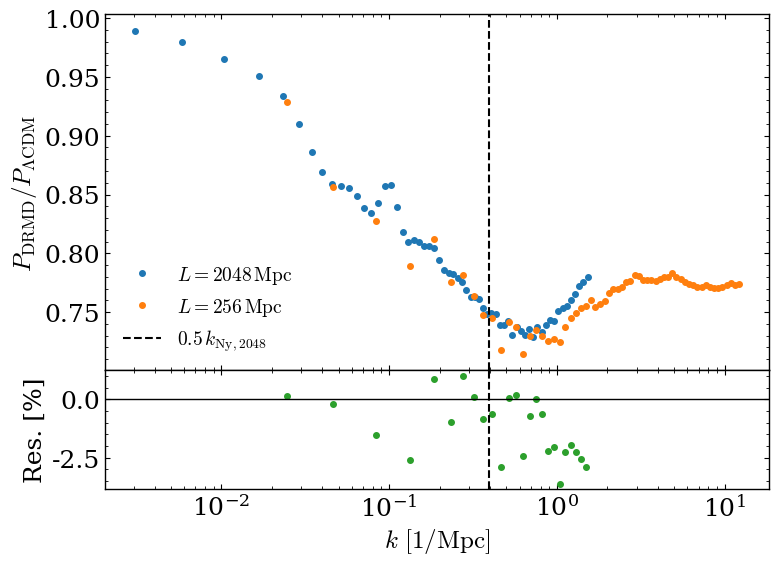

In [ ]:
# --- 2. File Paths and Parameters ---
filename = "powerspec_size512_lpt2_a=1.000"
base_dir = r"/home/storgaard/OneDrive/concept/grendel_output"

path_256 = os.path.join(base_dir, "256", "baseline", "powerspec", filename)
path_2048 = os.path.join(base_dir, "2048", "baseline", "powerspec", filename)
path_256_planck = os.path.join(base_dir, "256", "planck", "powerspec", filename)
path_2048_planck = os.path.join(base_dir, "2048", "planck", "powerspec", filename)

# Numerical Parameters
N_part_1D = 512
L_large = 2048.0
L_small = 256.0

k_ny_2048 = np.pi * N_part_1D / L_large
k_cut = 0.5 * k_ny_2048

# --- 3. Load Data ---
data_256 = np.loadtxt(path_256)
k_256 = data_256[:, 0]
Pk_256 = data_256[:, 3]

k_planck_256 = np.loadtxt(path_256_planck)[:, 0]
Pk_planck_256 = np.loadtxt(path_256_planck)[:, 3]

data_2048 = np.loadtxt(path_2048)
k_2048 = data_2048[:, 0]
Pk_2048 = data_2048[:, 3]

k_planck_2048 = np.loadtxt(path_2048_planck)[:, 0]
Pk_planck_2048 = np.loadtxt(path_2048_planck)[:, 3]

# Calculate the ratios (baseline / planck) to cancel cosmic variance
ratio_2048 = Pk_2048 / Pk_planck_2048
ratio_256 = Pk_256 / Pk_planck_256

# --- 4. Calculate Overlap Residual ---
# The overlap is strictly bounded by the lowest k of the small box 
# and the highest k of the large box.
k_overlap_min = np.min(k_256)
k_overlap_max = np.max(k_2048)

mask_256_overlap = (k_256 >= k_overlap_min) & (k_256 <= k_overlap_max)
k_256_overlap = k_256[mask_256_overlap]
ratio_256_overlap = ratio_256[mask_256_overlap]

# Interpolate the large box RATIO onto the small box k-bins.
# Using log10(k) for interpolation is essential for cosmological scales.
ratio_2048_interp = np.interp(np.log10(k_256_overlap), np.log10(k_2048), ratio_2048)

# Calculate the fractional difference of the ratios
residual = ((ratio_256_overlap / ratio_2048_interp) - 1) * 100

# --- 5. Plotting ---
fig = plt.figure(figsize=(8, 6), layout="constrained")
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.0)

ax_main = fig.add_subplot(gs[0, 0])
ax_res = fig.add_subplot(gs[1, 0], sharex=ax_main)

# Main Panel
ax_main.semilogx(k_2048, ratio_2048, label=r"$L = 2048 \, \mathrm{Mpc}$", color='tab:blue', ls = 'None', marker = 'o', markersize = 4)
ax_main.semilogx(k_256, ratio_256, label=r"$L = 256 \, \mathrm{Mpc}$", color='tab:orange', ls = 'None', marker = 'o', markersize = 4)

# Cutoff line
ax_main.axvline(k_cut, color='k', linestyle='--', lw=1.5, label=r"$0.5 \, k_{\mathrm{Ny, 2048}}$")

# Updated label to reflect the ratio being plotted
ax_main.set_ylabel(r"$P_{\mathrm{DRMD}} / P_{\Lambda\mathrm{CDM}}$")
ax_main.legend(loc='lower left')
ax_main.tick_params(labelbottom=False)

# Residual Panel
ax_res.semilogx(k_256_overlap, residual, color='tab:green', marker='o', markersize=4, ls = 'None')
ax_res.axhline(0, color='k', lw=1.0)
ax_res.axvline(k_cut, color='k', linestyle='--', lw=1.5)

ax_res.set_ylabel(r"Res. [%]")
ax_res.set_xlabel(r"$k \ [1/\mathrm{Mpc}]$")

plt.tight_layout()
# plt.savefig('box_stitching_validation.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [38]:
k_overlap_min, k_overlap_max

np.pi * N_part_1D / L_large

0.7853981633974483